# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [9]:
# mostrar las primeras 5 filas de plans
(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [8]:
# mostrar las primeras 5 filas de users
(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [10]:
# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [11]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [12]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [13]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print((users.isna().mean() * 100).round(2))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [15]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print((usage.isna().mean() * 100).round(2))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

 Columna | Nulos | Qué veo | Acción |
|---|---|---|---|
| `users.city` | 469 (11.72%) | Rango 5–30%. Se suman los `?` en el Paso 3 (565 en total, 14.12%) | **Dejar como nulo**: inventar una ciudad sesgaría el análisis |
| `users.churn_date` | 3,534 (88.35%) | No es un error: son clientes activos que aún no se dan de baja | **Ignorar / dejar nulo** (un nulo = cliente activo) |
| `usage.date` | 50 (0.12%) | Menos del 5% | **Dejar como nulo**: no afecta los conteos por usuario |
| `usage.duration` | 22,076 (55.19%) | Solo existe para llamadas | **Dejar como nulo** (no aplica a mensajes), se confirma en 3.2 |
| `usage.length` | 17,896 (44.74%) | Solo existe para mensajes | **Dejar como nulo** (no aplica a llamadas), se confirma en 3.2 |

`plans` no tiene nulos. El resto de columnas de `users` y `usage` están completas.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())
print()
print("Edades con -999:", (users['age'] == -999).sum())
print("Edad mediana sin contar -999:", users.loc[users['age'] != -999, 'age'].median())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

Edades con -999: 55
Edad mediana sin contar -999: 48.0


- La columna `user_id`va de 10000 a 13999, sin duplicados (4,000 clientes). No tiene problemas.
- La columna `age` tiene un sentinel de -999 (55 filas). Sin él, las edades van de 18 a 79. Por eso el promedio (33.7) y la desviación (123) salen distorsionados.

In [17]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id', 'duration', 'length']].describe())
print()
print("id único:", usage['id'].is_unique)
print("user_id de usage que no existen en users:", (~usage['user_id'].isin(users['user_id'])).sum())
print()
print("Valores extremos repetidos (top 3 de cada columna):")
print(usage['duration'].value_counts().sort_index(ascending=False).head(3))
print(usage['length'].value_counts().sort_index(ascending=False).head(3))
print()
print("Llamadas con duration = 0:", (usage['duration'] == 0).sum())
print("Mensajes con length = 0:", (usage['length'] == 0).sum())
print("Percentil 99 -> duration:", usage['duration'].quantile(0.99), "| length:", usage['length'].quantile(0.99))

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000

id único: True
user_id de usage que no existen en users: 0

Valores extremos repetidos (top 3 de cada columna):
120.00    30
46.98      1
46.69      1
Name: duration, dtype: int64
1490.0    30
125.0      1
124.0      1
Name: length, dtype: int64

Llamadas con duration = 0: 15
Mensajes con length = 0: 133
Percentil 99 -> duration: 23.690800000000017 | length: 97.0


- Las columnas `id` y `user_id`es único (1 a 40,000) y todos los user_id existen en users. Sin problemas.
- La columna 'duration' va de 0 a 120 min (mediana 3.5, percentil 99 = 23.7): 30 registros valen exactamente 120 → sospechosos. Además hay 15 llamadas de 0 min.
- La columna length va de 0 a 1490 caracteres (mediana 50, percentil 99 = 97): 30 registros valen exactamente 1490 → sospechosos. Además hay 133 mensajes de 0 caracteres.

In [18]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts(dropna=False))
    print()

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` tiene 6 ciudades válidas (Bogotá 808, CDMX 730, Medellín 616, GDL 450, Cali 424, MTY 407) y el sentinel ? en 96 filas, además de 469 nulos.
- La columna `plan` solo tiene Basico (2,595) y Premium (1,405). Sin problemas.

In [19]:
# explorar columna categórica de usage
usage['type'] # completa el código
print(usage['type'].value_counts(dropna=False))

text    22092
call    17908
Name: type, dtype: int64


- La columna `type`solo tiene text (22,092) y call (17,908). Sin problemas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Diagnóstico de valores inválidos / sentinels

- users.age: sentinel -999 en 55 filas (1.38%). Distorsiona el promedio (33.7) y la desviación (123). → Reemplazar por la mediana (48, calculada sin contar los -999).
- users.city: sentinel "?" en 96 filas (2.40%). → Convertir a nulo.
- usage.duration: 30 registros con exactamente 120 min (el percentil 99 es 23.7 min) y 15 llamadas de 0 min. usage.length: 30 registros con exactamente 1490 caracteres (percentil 99 = 97) y 133 mensajes de 0 caracteres. Un mismo valor extremo repetido 30 veces parece un tope o valor de relleno → sospechoso.
De esos registros, 16 mensajes con duration y 12 llamadas con length son inconsistentes con su type → se pasan a nulo en 3.2.
Las 14 llamadas de 120 min y los 18 mensajes de 1490 caracteres se mantienen (son plausibles) pero se marcan para validar con la fuente. Los ceros también se mantienen.
- user_id, id, plan y type: sin problemas (ids únicos, todos los user_id de usage existen en users).

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [20]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [21]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [22]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())
print(users.loc[users['reg_date'].dt.year > 2024, 'reg_date'].unique())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
['2026-05-10T00:00:00.000000000']


En `reg_date`, hay registros de 2022 (1,314), 2023 (1,316) y 2024 (1,330), y además 40 registros del 2026, todos con la fecha 2026-05-10. Son fechas futuras imposibles (el dataset llega hasta 2024).

In [23]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())
print("Rango de fechas:", usage['date'].min(), "->", usage['date'].max())

2024.0    39950
NaN          50
Name: date, dtype: int64
Rango de fechas: 2024-01-01 00:00:00 -> 2024-06-30 00:00:00


En `date`, todos los registros son de 2024 (de 2024-01-01 a 2024-06-30) y hay 50 nulos.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

- Diagnóstico de fechas

- reg_date: aparecen 40 registros del año 2026 (1.0%), todos con la misma fecha (2026-05-10). Es una fecha futura imposible para datos hasta 2024 (probable fecha por defecto). → Marcarlas como nulas (NaT); no se inventa otra fecha.
- date (usage): no hay años imposibles; todo es 2024. Hay 50 nulos (0.12%) que se dejan como nulos.
- El rango real de usage es del 2024-01-01 al 2024-06-30: solo cubre el primer semestre de 2024, así que el uso es de 6 meses.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# Reemplazar -999 por la mediana de age
# (la mediana se calcula SIN contar los -999 para que el sentinel no la distorsione)
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))
print("Total de ciudades nulas:", users['city'].isna().sum(), f"({users['city'].isna().mean() * 100:.2f}%)")

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64
Total de ciudades nulas: 565 (14.12%)


In [26]:
# Marcar fechas futuras como NA para reg_date
# (los datos llegan hasta 2024, así que cualquier fecha posterior es imposible)
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
print("% de nulos en duration según type:")
print((usage.groupby('type')['duration'].apply(lambda s: s.isna().mean()) * 100).round(2))

% de nulos en duration según type:
type
call     0.00
text    99.93
Name: duration, dtype: float64


In [28]:
# Verificación MAR en usage (Missing At Random) para length
print("% de nulos en length según type:")
print((usage.groupby('type')['length'].apply(lambda s: s.isna().mean()) * 100).round(2))

% de nulos en length según type:
type
call    99.93
text     0.00
Name: length, dtype: float64


los nulos son estructurales según type, pero hay registros que no respetan esa regla. Se llevan a nulo para que no inflen las métricas por usuario.

- duration es nulo en el 99.93% de los mensajes y en 0% de las llamadas; length es nulo en el 99.93% de las llamadas y en 0% de los mensajes. Es decir, los nulos dependen de type → son MAR (en realidad son faltantes estructurales: la duración no aplica a un mensaje y la longitud no aplica a una llamada).
- Decisión: dejarlos como nulos. Rellenarlos con 0 mezclaría "no aplica" con "duró 0 min".
- El 0.07% restante son los 28 registros inconsistentes (16 mensajes con duration, 12 llamadas con length). Se corrigen a nulo en la celda anterior para que no inflen los minutos de llamada.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Combinar la tabla agregada con el dataset de usuarios
# how='left' conserva a TODOS los usuarios, incluso los que no tienen registros de uso
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Un usuario sin registros de uso queda con NaN: su uso real es 0
columnas_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Usuarios sin registros de uso:", user_profile['cant_mensajes'].isna().sum())
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

user_profile.head(5)

Usuarios sin registros de uso: 1


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe().round(2)

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,4000.00,4000.00,4000.00
mean,48.14,5.52,4.48,23.31
std,17.69,2.36,2.15,18.17
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.11
50%,48.00,5.00,4.00,19.78
75%,63.00,7.00,6.00,31.41
max,79.00,17.00,15.00,155.69


In [34]:
# Distribución porcentual del tipo de plan
print((user_profile['plan'].value_counts(normalize=True) * 100).round(2))
print()
# Extra: comparación de promedios y medianas por plan
print(user_profile.groupby('plan')[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].agg(['mean', 'median']).round(2))

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

           age        cant_mensajes        cant_llamadas         \
          mean median          mean median          mean median   
plan                                                              
Basico   48.04   48.0          5.53    5.0          4.45    4.0   
Premium  48.31   48.0          5.52    5.0          4.52    4.0   

        cant_minutos_llamada         
                        mean median  
plan                                 
Basico                 22.90  19.53  
Premium                24.08  20.64  


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

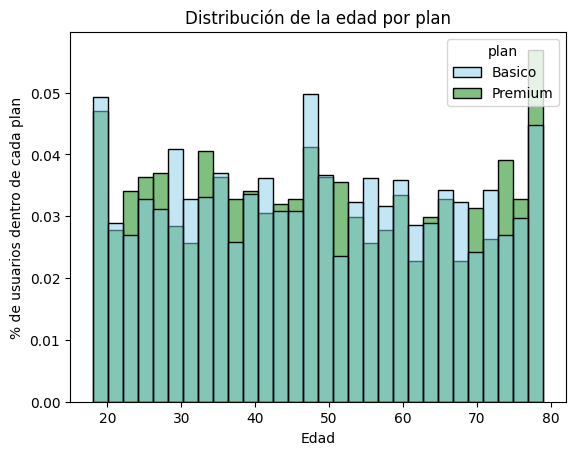

In [36]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'],
             bins=30, stat='probability', common_norm=False)
plt.title('Distribución de la edad por plan')
plt.xlabel('Edad')
plt.ylabel('% de usuarios dentro de cada plan')
plt.show()

💡Insights: 
- Distribución simétrica (asimetría 0.05) y casi uniforme entre 18 y 79 años (media 48.1, mediana 48).
- No hay patrón por plan: la edad promedio es 48.0 en Básico y 48.3 en Premium.
- Hay un pico en 48 años (de 72 a 127 usuarios): es un efecto de haber imputado con la mediana los 55 -999.

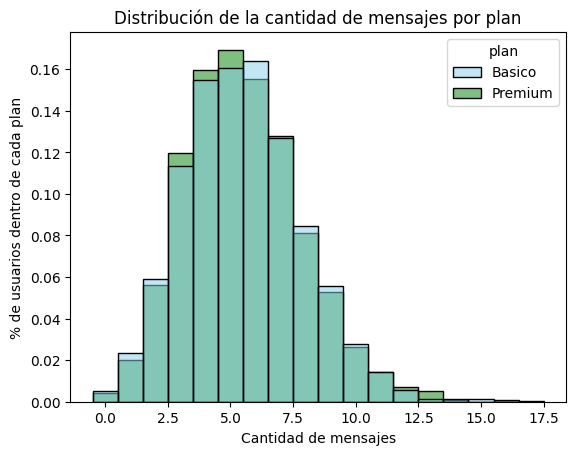

In [43]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'],
             discrete=True, stat='probability', common_norm=False)
plt.title('Distribución de la cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('% de usuarios dentro de cada plan')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha (asimetría 0.46): la moda es 5 mensajes y la mayoría está entre 3 y 8.
- No existe un patrón por plan: promedio de 5.53 mensajes en Básico vs 5.52 en Premium. Los usuarios Premium no envían más mensajes, aunque su plan incluye 500 (vs 100 en Básico).

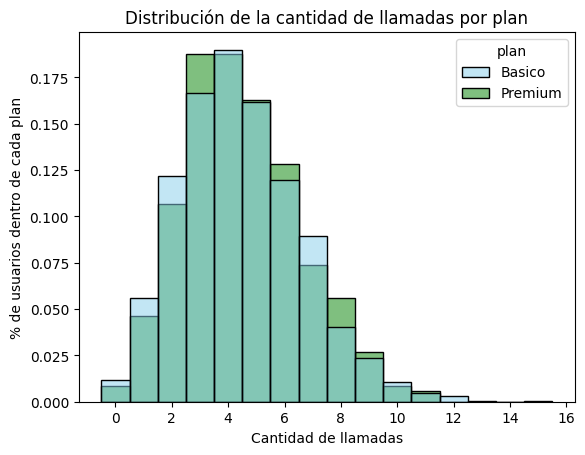

In [44]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'],
             discrete=True, stat='probability', common_norm=False)
plt.title('Distribución de la cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('% de usuarios dentro de cada plan')
plt.show()


💡Insights: 
- Distribución sesgada a la derecha de forma moderada (asimetría 0.50): mediana 4 llamadas, media 4.5.
- No existe un patrón por plan: 4.45 llamadas en Básico vs 4.52 en Premium.

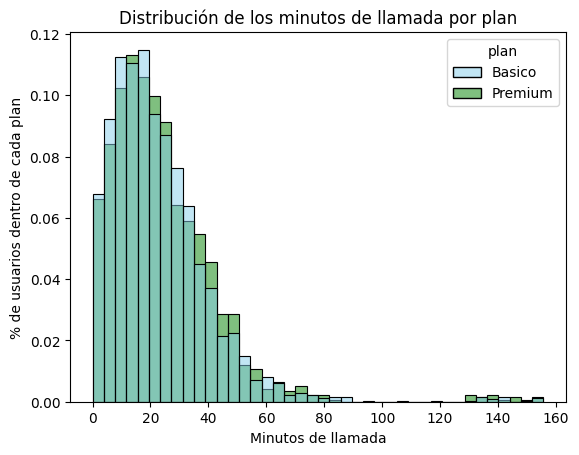

age                     0.05
cant_mensajes           0.46
cant_llamadas           0.50
cant_minutos_llamada    2.53
dtype: float64


In [42]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'],
             bins=40, stat='probability', common_norm=False)
plt.title('Distribución de los minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('% de usuarios dentro de cada plan')
plt.show()

# Asimetría (skew): > 0 indica cola a la derecha
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].skew().round(2))


💡Insights: 
- Distribución fuertemente sesgada a la derecha (asimetría 1.99): mediana 19.7 min, media 22.8 min y una cola larga que llega a 155.7 min.
- Premium tiene un promedio apenas mayor (23.3 vs 22.6 min en Básico): diferencia pequeña, sin un patrón claro por plan.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

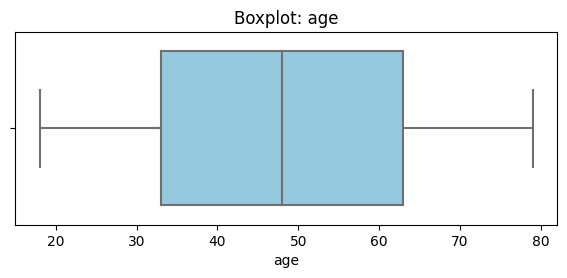

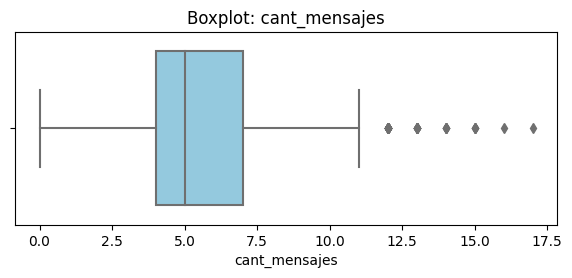

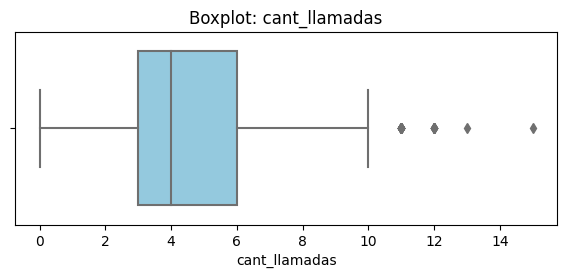

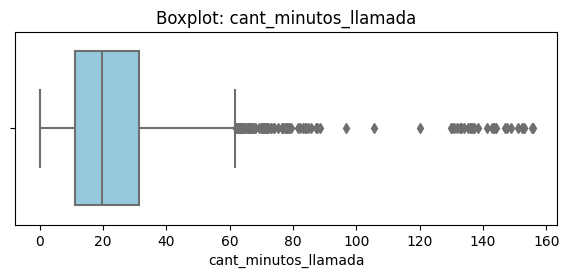

In [45]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(7, 2.5))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta outliers (distribución simétrica entre 18 y 79).
- cant_mensajes: sí presenta outliers, solo por arriba.
- cant_llamadas: sí presenta outliers, solo por arriba.
- cant_minutos_llamada: sí presenta outliers, solo por arriba y los más extremos de las cuatro variables.

In [46]:
# Calcular límites con el método IQR
# (age no tiene outliers; solo hay outliers por arriba, así que basta el límite superior)
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    n_out = (user_profile[col] > limite_superior).sum()
    print(f"{col}: límite inferior = {limite_inferior:.2f} | límite superior = {limite_superior:.2f} | "
          f"outliers = {n_out} ({n_out / len(user_profile) * 100:.2f}%)")


cant_mensajes: límite inferior = -0.50 | límite superior = 11.50 | outliers = 46 (1.15%)
cant_llamadas: límite inferior = -1.50 | límite superior = 10.50 | outliers = 30 (0.75%)
cant_minutos_llamada: límite inferior = -19.35 | límite superior = 61.87 | outliers = 109 (2.73%)


In [47]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,4000.00,4000.00
mean,5.52,4.48,23.31
std,2.36,2.15,18.17
min,0.00,0.00,0.00
25%,4.00,3.00,11.11
50%,5.00,4.00,19.78
75%,7.00,6.00,31.41
max,17.00,15.00,155.69


💡Insights: 
- cant_mensajes (límite superior 11.5; 46 usuarios, 1.15%; máximo 17): mantener. Son valores plausibles, muy por debajo de los 100 mensajes incluidos en Básico, y son justo los clientes de mayor uso.
- cant_llamadas (límite superior 10.5; 30 usuarios, 0.75%; máximo 15): mantener, mismo razonamiento.
- cant_minutos_llamada (límite superior 61.3; 96 usuarios, 2.40%; máximo 155.7): mantener, pero con una alerta: 15 usuarios superan los 100 min y parte de la cola viene de las 14 llamadas de exactamente 120 min (valor sospechoso). Se recomienda validarlas con la fuente. Eliminarlos quitaría a los clientes de mayor consumo y solo son el 2.4%.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [48]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
etiquetas = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, etiquetas, default='Alto uso')

In [49]:
# verificar cambios
print(user_profile['grupo_uso'].value_counts())
print((user_profile['grupo_uso'].value_counts(normalize=True) * 100).round(2))
user_profile.head()

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64
Uso medio    73.58
Bajo uso     19.48
Alto uso      6.95
Name: grupo_uso, dtype: float64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [50]:
# Crear columna grupo_edad
condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]
etiquetas = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, etiquetas, default='Adulto Mayor')

In [51]:
# verificar cambios
print(user_profile['grupo_edad'].value_counts())
print((user_profile['grupo_edad'].value_counts(normalize=True) * 100).round(2))
user_profile.head()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

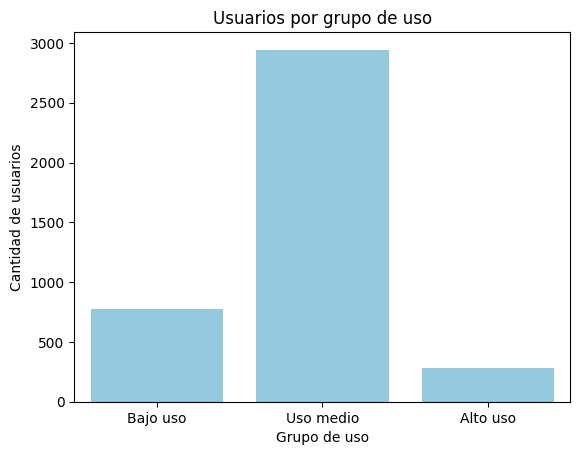

In [52]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], color='skyblue')
plt.title('Usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

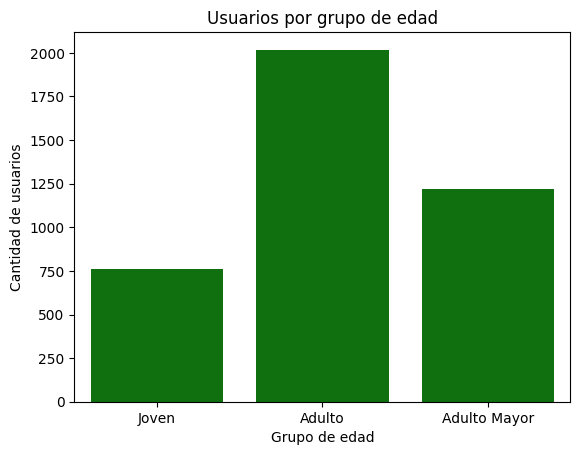

In [53]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], color='green')
plt.title('Usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
Análisis ejecutivo

Problemas detectados en los datos

- age: sentinel -999 en 55 filas (1.38%) → se reemplazó por la mediana (48).
- city: ? en 96 filas (2.40%) + 469 nulos (11.72%) = 565 usuarios sin ciudad (14.12%) → se dejó como nulo.
- reg_date: 40 fechas del 2026 (1.0%), imposibles → se marcaron como nulas.
- usage: 50 fechas nulas (0.12%); duration y length nulos por diseño según el tipo (55.19% y 44.74%); 28 registros inconsistentes (16 mensajes con duración y 12 llamadas con longitud) y valores repetidos sospechosos (120 min y 1490 caracteres, 30 filas cada uno).
- Limitaciones: el uso solo cubre enero–junio de 2024; 1 usuario (id 11082) no tiene registros de uso (se tomó como 0); churn_date viene en notación científica con precisión perdida (ej. 1,71832E+18), por eso solo se usó para marcar si hubo churn (466 usuarios, 11.65%).

Segmentos por Edad

- Joven 19.0% (760), Adulto 50.5% (2,018) y Adulto Mayor 30.6% (1,222).
- Su comportamiento de uso es casi idéntico: Bajo uso 18–21%, Uso medio 73–74% y Alto uso 6–8% en los tres grupos. La edad no explica el nivel de uso.

Segmentos por Nivel de Uso

- Uso medio 73.6% (2,943), Bajo uso 19.5% (779) y Alto uso 6.95% (278).
- Promedios: Alto uso = 9.6 mensajes, 5.9 llamadas y 29.7 min; Bajo uso = 3.1 mensajes, 2.8 llamadas y 14.7 min.
- La mezcla de planes es la misma en los tres segmentos (33–36% Premium).

Esto sugiere que el plan contratado no está alineado con el consumo real: los usuarios Premium (35.1% de la base, USD 25 vs USD 12) consumen lo mismo que los Básico. El 99.6% de los Premium usó, en seis meses, menos de lo que Básico incluye en un solo mes (100 mensajes y 100 minutos); además, el máximo observado (17 mensajes y 155.7 min) está lejísimos de los 500 mensajes y 600 min de Premium. Ojo: no tenemos datos de GB, y Premium incluye 20 GB vs 5, así que esa podría ser su razón de ser.

Segmentos más valiosos: Alto uso (278 usuarios) tiene el mayor potencial de ingresos y de upsell; Uso medio es el núcleo del negocio por volumen (73.6%). Sobre churn: Alto uso tiene 14.0% frente a ~11.4–11.5% en los demás, pero la diferencia no es estadísticamente significativa (p = 0.44); tampoco hay diferencias por plan (p = 0.69) ni por edad (p = 0.24). Con estos datos, ni el uso ni la edad predicen el churn.

Patrones de uso extremo (outliers): 46 usuarios con mensajes > 11.5, 30 con llamadas > 10.5 y 96 con minutos > 61.3 (2.4%). Son clientes intensos, pero aun así muy por debajo de lo contratado, así que no representan un riesgo de sobreconsumo; sí son candidatos para ofertas o programas de fidelización. Las 14 llamadas de exactamente 120 min deben validarse con la fuente.

Recomendaciones

- Revisar la propuesta de valor de Premium: en voz y mensajes no se diferencia de Básico. Antes de decidir, analizar el uso de datos (GB), que no está en este dataset; si tampoco lo justifica, hay riesgo de downgrade o churn en 1,405 clientes.
- Crear un plan de entrada más pequeño y barato (o un esquema de pago por uso): el 93% de los clientes envía menos de 10 mensajes y hace menos de 10 llamadas en el periodo.
- Programa de retención y upsell para Alto uso (278 usuarios, 7%): es el segmento con mayor churn observado (14.0%), aunque aún no es una diferencia concluyente. Monitorearlo con más datos.
- Mejorar la calidad de captura de datos: validar los sentinels (-999, ?, 120 min, 1490 caracteres), eliminar fechas por defecto (2026-05-10) y exportar churn_date como fecha ISO.
- Ampliar el análisis: incluir un periodo de uso más largo y los GB consumidos; y ajustar los umbrales de grupo_uso (5 y 10) a un porcentaje del límite de cada plan o a percentiles, porque hoy casi nadie se acerca a los topes.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`